In [ ]:
# All imports
import kagglehub
from pathlib import Path
import matplotlib.pyplot as plt
from collections import Counter
import torchvision.transforms as transforms
from PIL import Image
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from torchvision.datasets import ImageFolder
import random
import torch
import torchvision.models as models
import torch.nn as nn

In [14]:
# Download dataset
path = kagglehub.dataset_download("unclesamulus/blood-cells-image-dataset")
root = Path(path)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'blood-cells-image-dataset' dataset.
Path to dataset files: /kaggle/input/blood-cells-image-dataset


In [15]:
# Find every .jpg and note which folder it's in
# The root.rglob provides a path link to one image file (https://docs.python.org/3/library/pathlib.html#basic-use)
all_images = list(root.rglob("*.jpg"))

# Count the number of blood cell types extracted
counts = Counter() #https://realpython.com/python-counter/#constructing-counters
for img in all_images:
  class_name = img.parent.name
  counts[class_name] += 1

# From the kaggle dataset, add the number of images for each blood cell type
expected = {
    "neutrophil":   3329,
    "eosinophil":   3117,
    "ig":           2895,
    "platelet":     2348,
    "erythroblast": 1551,
    "monocyte":     1420,
    "basophil":     1218,
    "lymphocyte":   1214,
}

# Print results
for class_name, count in sorted(counts.items()):
    expected_count = expected.get(class_name)
    print(class_name, "- found:", count, "expected:", expected_count)

basophil - found: 1218 expected: 1218
eosinophil - found: 3117 expected: 3117
erythroblast - found: 1551 expected: 1551
ig - found: 2895 expected: 2895
lymphocyte - found: 1214 expected: 1214
monocyte - found: 1420 expected: 1420
neutrophil - found: 3329 expected: 3329
platelet - found: 2348 expected: 2348


bloodcells_dataset


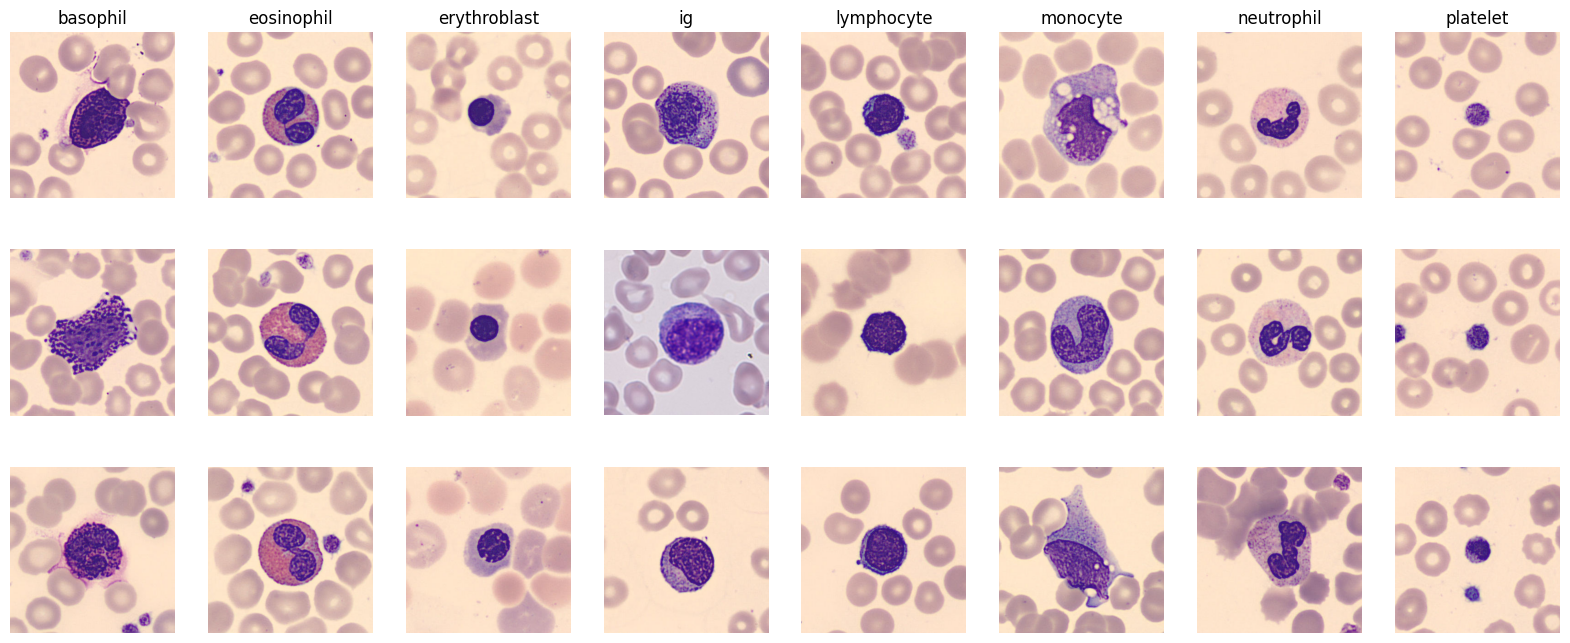

In [16]:
# Find the folder name of the dataset
for folder in sorted(root.iterdir()):
    print(folder.name)

# Get the class name from dict
class_names = sorted(counts.keys())

# Create a grid for images (3 rows, 8 columns) (https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html)
fig, axes = plt.subplots(3, 8, figsize=(20, 8))

# Loop to show 3 images from each category
for i, class_name in enumerate(sorted(counts.keys())):
    folder = root / "bloodcells_dataset" / class_name
    images = list(folder.glob("*.jpg"))[:3]

    for j in range(3):
        img = plt.imread(str(images[j]))
        axes[j, i].imshow(img)
        axes[j, i].axis("off")

    axes[0, i].set_title(class_name)

plt.show()

Preprocessing
- be resized to 224×224 pixels
- be normalized using ImageNet channel means and standard deviations (μ = [0.485, 0.456, 0.406], σ = [0.229, 0.224, 0.225])
- split into training and testing (90/10)

In [17]:
# Resize image and normalize https://docs.pytorch.org/vision/stable/transforms.html
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load all images with transforms applied
dataset = ImageFolder(root / "bloodcells_dataset", transform=transform)

# Pick 100 random images per class https://github.com/pytorch/vision/blob/main/torchvision/datasets/folder.py
indices = []
for class_idx in range(len(dataset.classes)):
    class_indices = [i for i, label in enumerate(dataset.targets) if label == class_idx]
    indices.extend(random.sample(class_indices, 100))

# Create the subset https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.Subset
subset = Subset(dataset, indices)
print("Total images:", len(subset))

# Split for training/testing
train_size = int(0.90 * len(subset))
test_size = len(subset) - train_size

train_dataset, test_dataset = random_split(subset, [train_size, test_size])

print("Train images:", len(train_dataset))
print("Test images:", len(test_dataset))

Total images: 800
Train images: 720
Test images: 80


In [18]:
# Dataloader https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html
# This guy has simple tutorial: https://ankushmulkar.medium.com/transfer-learning-for-images-using-pytorch-step-by-step-guide-3cfa485cbf5d
dataloader = DataLoader(subset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Number of batches: 25
Images per batch: 32
Total images: 800
Batch shape: torch.Size([32, 3, 224, 224])
Labels: tensor([6, 1, 7, 3, 1, 6, 1, 2, 2, 1, 5, 1, 0, 0, 1, 6, 5, 6, 1, 4, 4, 0, 7, 1,
        7, 3, 4, 1, 3, 7, 5, 6])


In [19]:
# Load VGG
# https://docs.pytorch.org/vision/stable/models.html
# https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html
# https://github.com/pytorch/vision/blob/main/torchvision/models/vgg.py

# Load VGG16 with pretrained ImageNet weights
model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

# Freeze all the pretrained layers so they don't change during training
for param in model.features.parameters():
    param.requires_grad = False

# Replace the classifier head for 8 classes instead of 1000
model.classifier[6] = nn.Linear(4096, 8)

print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1